In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [50]:
ipl = pd.read_csv('ipl-matches.csv')

In [51]:
ipl.head(960)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,335986,Kolkata,2008-04-20,2007/08,4,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Deccan Chargers,bat,N,Kolkata Knight Riders,Wickets,5.0,NaN,DJ Hussey,"['WP Saha', 'BB McCullum', 'RT Ponting', 'SC G...","['AC Gilchrist', 'Y Venugopal Rao', 'VVS Laxma...",BF Bowden,K Hariharan
946,335985,Mumbai,2008-04-20,2007/08,5,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,N,Royal Challengers Bangalore,Wickets,5.0,NaN,MV Boucher,"['L Ronchi', 'ST Jayasuriya', 'DJ Thornely', '...","['S Chanderpaul', 'R Dravid', 'LRPL Taylor', '...",SJ Davis,DJ Harper
947,335984,Delhi,2008-04-19,2007/08,3,Delhi Daredevils,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,N,Delhi Daredevils,Wickets,9.0,NaN,MF Maharoof,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...","['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Aleem Dar,GA Pratapkumar
948,335983,Chandigarh,2008-04-19,2007/08,2,Kings XI Punjab,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,N,Chennai Super Kings,Runs,33.0,NaN,MEK Hussey,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...","['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",MR Benson,SL Shastri


In [52]:
ipl[ipl['TossWinner'] == ipl['WinningTeam']].shape[0] / ipl['TossWinner'].shape[0] * 100

51.473684210526315

In [53]:
Most_Winning_Team = ipl['WinningTeam'].mode()[0]
print(Most_Winning_Team)

Mumbai Indians


In [54]:
Most_Match_Hosting_City = ipl['City'].mode()[0]
print(Most_Match_Hosting_City)

Mumbai


In [55]:
ipl.groupby('Season')['Margin'].mean()

Season
2007/08    15.965517
2009       16.857143
2009/10    19.762712
2011       18.930556
2012       16.229730
2013       19.837838
2014       14.728814
2015       17.821429
2016       15.333333
2017       17.103448
2018       14.350000
2019       15.210526
2020/21    22.589286
2021       13.576271
2022       16.972973
Name: Margin, dtype: float64

In [56]:
the_team_that_lost_toss_but_won_match = ipl[ipl['TossWinner'] != ipl['WinningTeam']].shape[0]

print(the_team_that_lost_toss_but_won_match)


461


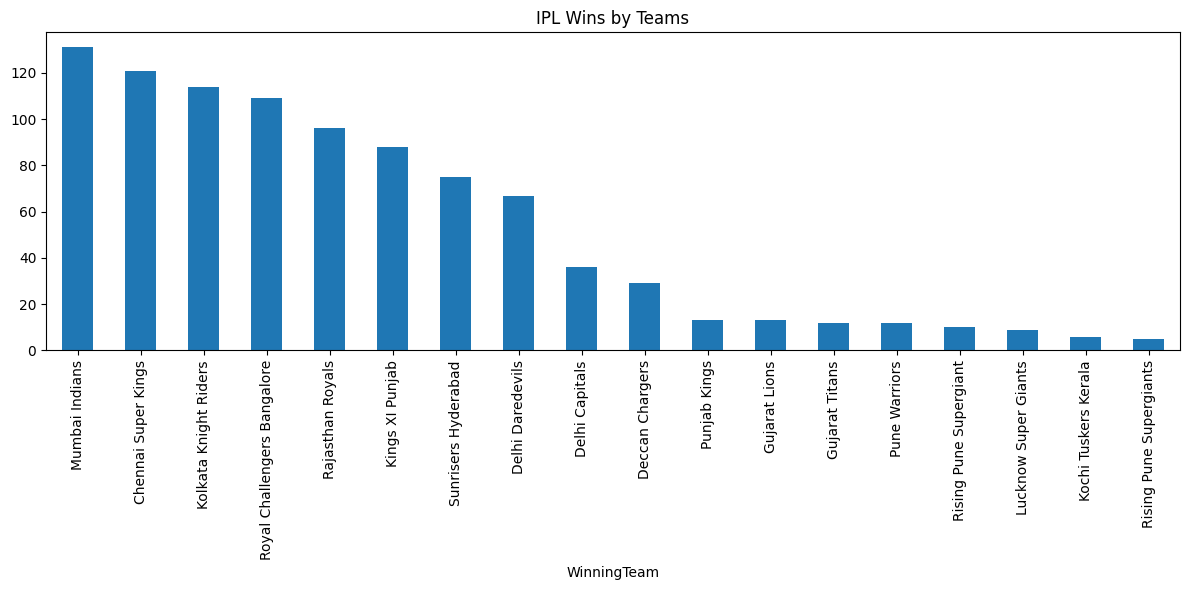

In [57]:
ipl['WinningTeam'].value_counts().plot(kind = 'bar', figsize=(12, 6))
plt.title('IPL Wins by Teams')
plt.tight_layout()
plt.show()

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [59]:
X = ipl[['Margin']]
y = ipl['Season']


In [60]:
ipl['Margin'] = pd.to_numeric(ipl['Margin'],
errors='coerce')
X = ipl['Season'] = pd.to_numeric(ipl['Season'],
errors='coerce')

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
X = X.fillna(X.mean())
y = y.fillna(y.mean())

TypeError: Cannot perform reduction 'mean' with string dtype

In [ ]:
# 1. Select your features and target
# Double brackets for X to keep it 2D
X = ipl[['Margin']]
y = ipl['Season']

# 2. Combine them temporarily to drop rows where EITHER is NaN
clean_df = ipl[['Margin', 'Season']].dropna()

# 3. Re-assign X and y from the cleaned dataframe
X_clean = clean_df[['Margin']]
y_clean = clean_df['Season']

# 4. Split the CLEANED data
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

# 5. Fit the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Success! Model is trained.")

Success! Model is trained.


In [ ]:
predictions = model.predict(X_test)
residuals = y_test - predictions

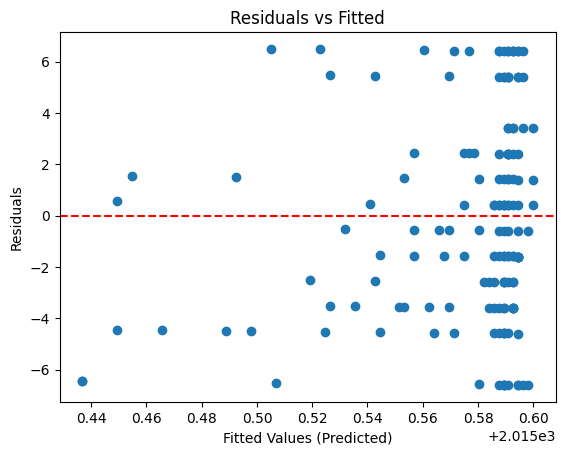

In [ ]:
plt.scatter(predictions, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Fitted')
plt.xlabel('Fitted Values (Predicted)')
plt.ylabel('Residuals')
plt.show()

Text(0.5, 1.0, 'Actual vs Predicted Comparison')

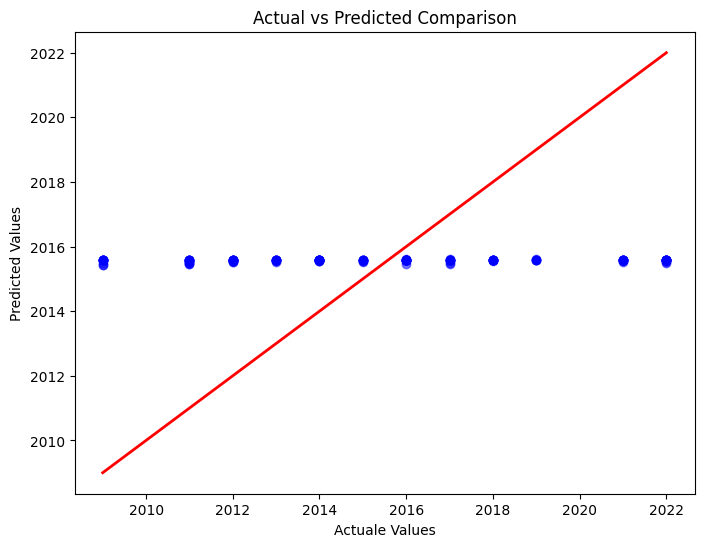

In [ ]:
'predictions' and 'y_test'
plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions, alpha=0.5, color='blue')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r-',lw=2)

plt.xlabel('Actuale Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Comparison')